# Capability 07 — Graph fraud

Executed evidence over synthetic golden fixtures. Transaction-only risk and
graph risk are scored by `src/telco_digital/intelligence/fraud`. No model is
trained or served. Graph ML remains out of scope.


In [1]:
from pathlib import Path
import json
from IPython.display import Image, display
from generate_outputs import main
from fixtures import GOLDEN
from telco_digital.intelligence.fraud import score_fraud

ROOT = Path(".")
main()
metrics = json.loads((ROOT / "outputs" / "metrics.json").read_text(encoding="utf-8"))
metrics


{'scorer_version': 'fraud-rules-v1',
 'prediction_set_version': 'customer-fraud-v1',
 'u009_risk_band': 'HIGH',
 'u009_transaction_risk': 0.335,
 'u009_graph_risk': 1.0,
 'u003_risk_band': 'LOW',
 'graph_exceeds_transaction_for_u009': True,
 'golden_customers': 4}

In [2]:
scores = json.loads((ROOT / "outputs" / "tables" / "golden_scores.json").read_text(encoding="utf-8"))
scores


[{'customer_ref': 'U009',
  'transaction_risk': 0.335,
  'graph_risk': 1.0,
  'combined_risk': 0.8005,
  'risk_band': 'HIGH',
  'fired_rules': ['KNOWN_FRAUD_WITHIN_2_HOPS', 'WALLET_FUNNEL'],
  'in_known_fraud_seed': True},
 {'customer_ref': 'U005',
  'transaction_risk': 0.0,
  'graph_risk': 0.58,
  'combined_risk': 0.406,
  'risk_band': 'MEDIUM',
  'fired_rules': ['SHARED_DEVICE', 'KNOWN_FRAUD_WITHIN_2_HOPS'],
  'in_known_fraud_seed': True},
 {'customer_ref': 'U001',
  'transaction_risk': 0.0,
  'graph_risk': 0.13,
  'combined_risk': 0.091,
  'risk_band': 'LOW',
  'fired_rules': ['SHARED_DEVICE'],
  'in_known_fraud_seed': False},
 {'customer_ref': 'U003',
  'transaction_risk': 0.085,
  'graph_risk': 0.0,
  'combined_risk': 0.0255,
  'risk_band': 'LOW',
  'fired_rules': [],
  'in_known_fraud_seed': False}]

In [3]:
u009 = score_fraud(*GOLDEN["U009"])
u003 = score_fraud(*GOLDEN["U003"])
assert u009.risk_band == "HIGH"
assert u009.graph_risk > u009.transaction_risk
assert u003.risk_band == "LOW"
{
    "u009_transaction_risk": u009.transaction_risk,
    "u009_graph_risk": u009.graph_risk,
    "u009_combined_risk": u009.combined_risk,
    "u003_risk_band": u003.risk_band,
}


{'u009_transaction_risk': 0.335,
 'u009_graph_risk': 1.0,
 'u009_combined_risk': 0.8005,
 'u003_risk_band': 'LOW'}

In [4]:
json.loads((ROOT / "outputs" / "tables" / "u009_rules.json").read_text(encoding="utf-8"))


[{'code': 'SHARED_DEVICE', 'fired': False, 'severity': 'low', 'boost': 0.0},
 {'code': 'KNOWN_FRAUD_WITHIN_2_HOPS',
  'fired': True,
  'severity': 'high',
  'boost': 0.15},
 {'code': 'WALLET_FUNNEL', 'fired': True, 'severity': 'high', 'boost': 0.15},
 {'code': 'CIRCULAR_TRANSFERS',
  'fired': False,
  'severity': 'high',
  'boost': 0.0},
 {'code': 'ABNORMAL_CREATION',
  'fired': False,
  'severity': 'medium',
  'boost': 0.0},
 {'code': 'ABNORMAL_TRANSACTION_VELOCITY',
  'fired': False,
  'severity': 'medium',
  'boost': 0.0}]

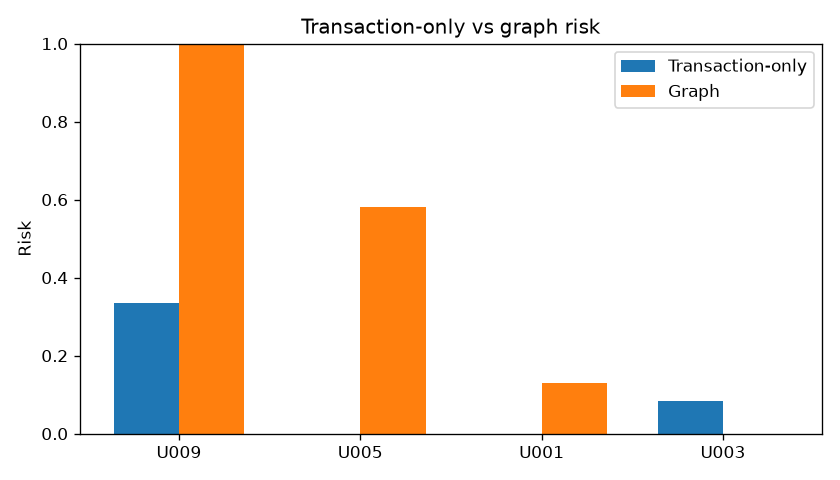

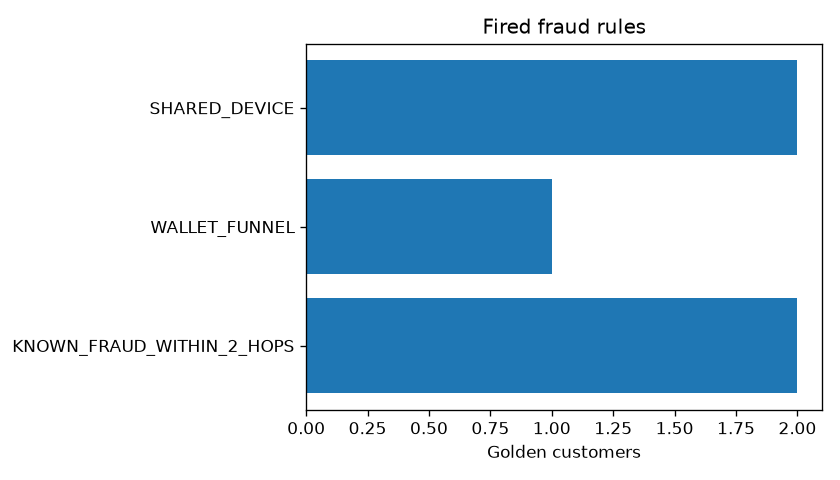

In [5]:
display(Image(filename=str(ROOT / "outputs" / "plots" / "transaction_vs_graph.png")))
display(Image(filename=str(ROOT / "outputs" / "plots" / "rule_firings.png")))
